# IND320 Assignment 1

## Introduction

This is a Jupyter Notebook for the first part of the IND320 - Data to Decision Project Work. This notebook includes:

* Links to Github repository and Streamlit app
* Description of AI Usage
* Reading of a reservoirs.csv file using pandas
* Plotting of various columns seperately and together for area types NO and EL in the CSV file

### Links to Github and Streamlit

Github: https://github.com/MagnusFrantsen/IND320-MagnusFrantsen  
Streamlit: https://ind320-magnusfrantsen.streamlit.app/

### Log Describing Compulsory Work

This section contains a log of the workflow with the Jupyter Notebook and Streamlitt App.

#### Jupyter Notebook

I started importing the pandas library and reading the data from the csv-file, renaming the columns, sorting the rows by date defined in the column renamed "Date", in the end i printed the first 20 rows to verify the mentioned steps.

Then I imported Matplotlib and created a subset of the dataframe by filtering and keeping only the rows with area_type 'NO'. This was a decision I made as there would have been a lot of noise and graphs if I was to plot all the graphs for all the area_types including all the area_nr. Then I plotted the Reservoir levels weekly for area_type 'NO'.

Furthermore, I created a subset el for area_type 'EL' and made a pivot table to plot weekly reservoir levels for all area numbers under area type 'EL'.

Finally i created two different subsets, one for the change in the reservoirs levels in area type 'NO' and one for previous reservoirs levels in area type 'NO'.

I considered next publish date, iso week and year as metadata for the other columns and therefore I did not plot any of these.

#### Streamlit App

First I connected the Github repository to Streamlit, troubleshooting with AI. To verify the connection I made a simple st.write('...') in the app.py and some simple input-field with some basic questions and it worked smoothly.

Regarding the Project Work, i first started creating a pages-folder to create a navigation bar on the left side of the App. Then I created a utils.py file including caching of data in utils.py file. 

Then I created the Imported Data Table file creating columns for selection of plot (area type and number) and filtering based on the selected area type and number. In the end of this page I used st.dataframe() to display the selected plot.

Second to last, I created the plots page for plotting of the data in the reservoirs.csv file. First I loaded the data by calling the function load_data from utils.py, then selecting area type 'NO' and filtering the imported dataframe based on area type. Then I created a column in the dataframe for months, used for sorting by months for the slider, which is then sorted. Then comes a dictionary for nicer names for the columns used for plotting. Later a start and end variable is defined which will be used to define the start and end of the time interval for plotting of columns. Then I created if-else statements to determine what should be the labels and legends when the data is plotted. And in the end I created a figure for plotting and plots are created through if and else statements and a for-loop if 'All' is selected for plotting. In the end i decide to have a grid in the plots and that the figure is shown using st.pyplot(fig).

Finally I created a dummy page as we were told to create four pages.

### AI Usage

AI models used during this assignment:

* Claude Sonnet 5 Medium
* Google Gemini 3.5 Flash-Lite

Generally, the AI models have also suggested code, I have copied and rewritten some of the code, but not much, as the models have often suggested different things from what I have actually asked for. I have tried to use it as little as possible for direct copying of code for the assignment. To give this summary of AI usage I have asked each chat for a summary of what it has been used for, and this has been shortened and rewritten by hand by me.

#### Claude Sonnet 5 Medium

For Claude Sonnet 5 i have had 4 different chats for different purposes:

1. Questions regarding Streamlit
    - How to create checkboxes, sliders and selectboxes
    - How to structure the directory/repository to make the app functional (pages folder with different .py files for each page)
    - Troubleshooting during deployment: Provided different error messages to the AI model, for instance FileNotFoundError, created to different ways to find the reservoirs.csv-file.
    - Formatting of figures and numbers
    - Placement/toggling of legends
    - Suggesting where to cache data using @st.cache_data

2. Functions and possibilites in python
    - How to filter a dataframe
    - How to set labels, legends, titles etc. for plotting
    - Explained how to use the LineChartColumn()
    - Helped troubleshooting dropdown, slider and matplotlib issues

3. Packages, Python, Jupyter Issues
    - Helped activating a virtual environment
    - Given different commands such as pip install for packages and requirements.txt file
    - Explained why the .venv/.gitignore makes sure the venv-folder is not pushed to Github
    - Explained why the .devcontainer folder should be pushed to Github and not the pycache folder

4. Jupyter Notebook Questions
    - How to Create headers in .ipynb-files
    - How to Create line shift in markdown cells

#### Google Gemini 3.5 Flash-Lite

Google Gemini 3.5 Flash-lite has been used for various small questions for troubleshooting, but not for direct generation of code.

## Tasks

In [34]:
# importing relevant library for this cell
import pandas as pd

# Reading the CSV-file and renaming the headers:
df = pd.read_csv("data/reservoirs.csv", header = 0)
df.columns = ['Date', 'area_type','area_nr', 'iso_year', 'iso_week', 
              'res_level', 'capacity_TWh', 'res_level_TWh', 
              'next_publish_date', 'prev_res_level', 'change_res_level']
# print(df.head()[0:4]) checked that data is read correctly

# Sorting the dataframe by date in ascending order
df = df.sort_values(by=['Date'], ascending=True)
df['Date'] = pd.to_datetime(df['Date'])

# Displaying the first 20 rows of the dataframe sorted by date 
# .to_string() is used to print the entire rows without truncation (have everything in one line)
print(df.head(20).to_string())

# Confirming that df is still a pandas dataframe after the sorting operation and printing
# print(type(df))

            Date area_type  area_nr  iso_year  iso_week  res_level  capacity_TWh  res_level_TWh    next_publish_date  prev_res_level  change_res_level
3113  1995-01-08        EL        1      1995         1   0.621467      6.003264       3.730831  0001-01-01T00:00:00        0.734888         -0.113421
3361  1995-01-08        EL        4      1995         1   0.558864     21.079208      11.780413  0001-01-01T00:00:00        0.801348         -0.242484
3468  1995-01-08        EL        5      1995         1   0.616448     17.390587      10.720388  0001-01-01T00:00:00        0.614288          0.002160
5036  1995-01-08        EL        3      1995         1   0.602376      8.920932       5.373754  0001-01-01T00:00:00        0.596027          0.006349
7739  1995-01-08        EL        2      1995         1   0.630947     34.043590      21.479713  0001-01-01T00:00:00        0.777604         -0.146657
8501  1995-01-08        NO        0      1995         1   0.608274     87.437580      53.18598

### Reservoirs levels (%) in Area Type NO

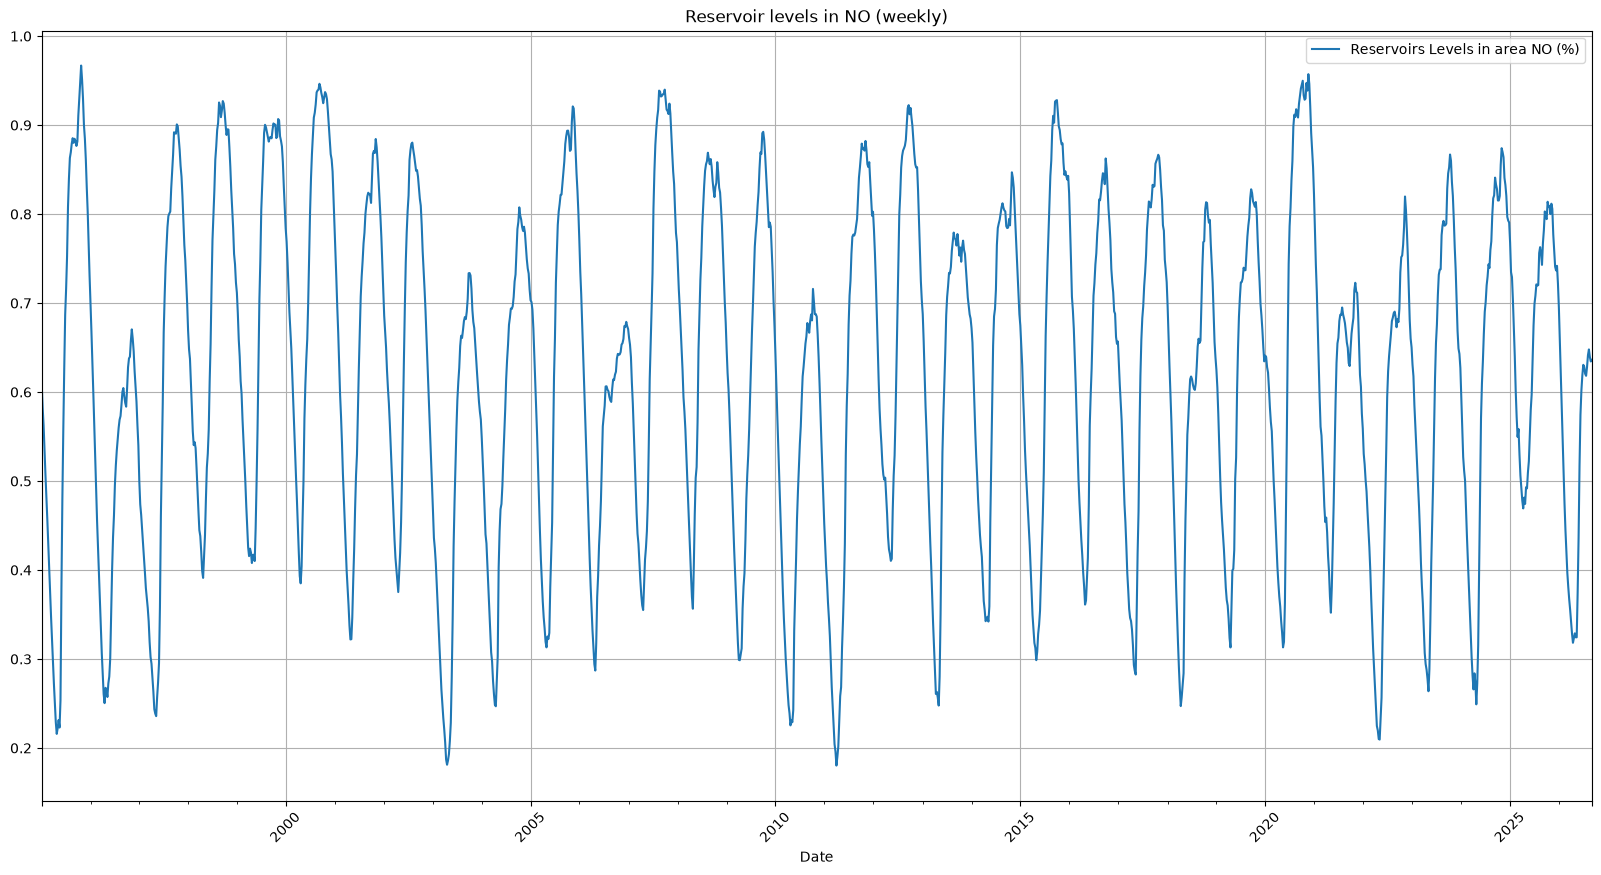

In [35]:
#importing matplolib.pyplot for plotting
import matplotlib.pyplot as plt

# Plotting the reservoir levels in NO over time
subset_1 = df[df['area_type'] == 'NO']

# Plotting reservoir levels in area type NO
ax1 = subset_1.plot(x='Date', 
              y='res_level', 
              kind='line', 
              title='Reservoir levels in NO (weekly)', 
              figsize=(20,10),
              rot=45, 
              grid=True)

# Renaming the legend to be easier to understand
ax1.legend(['Reservoirs Levels in area NO (%)'])

# Making sure the plot is shown
plt.show()

### Reservoirs levels in TWh in area type NO

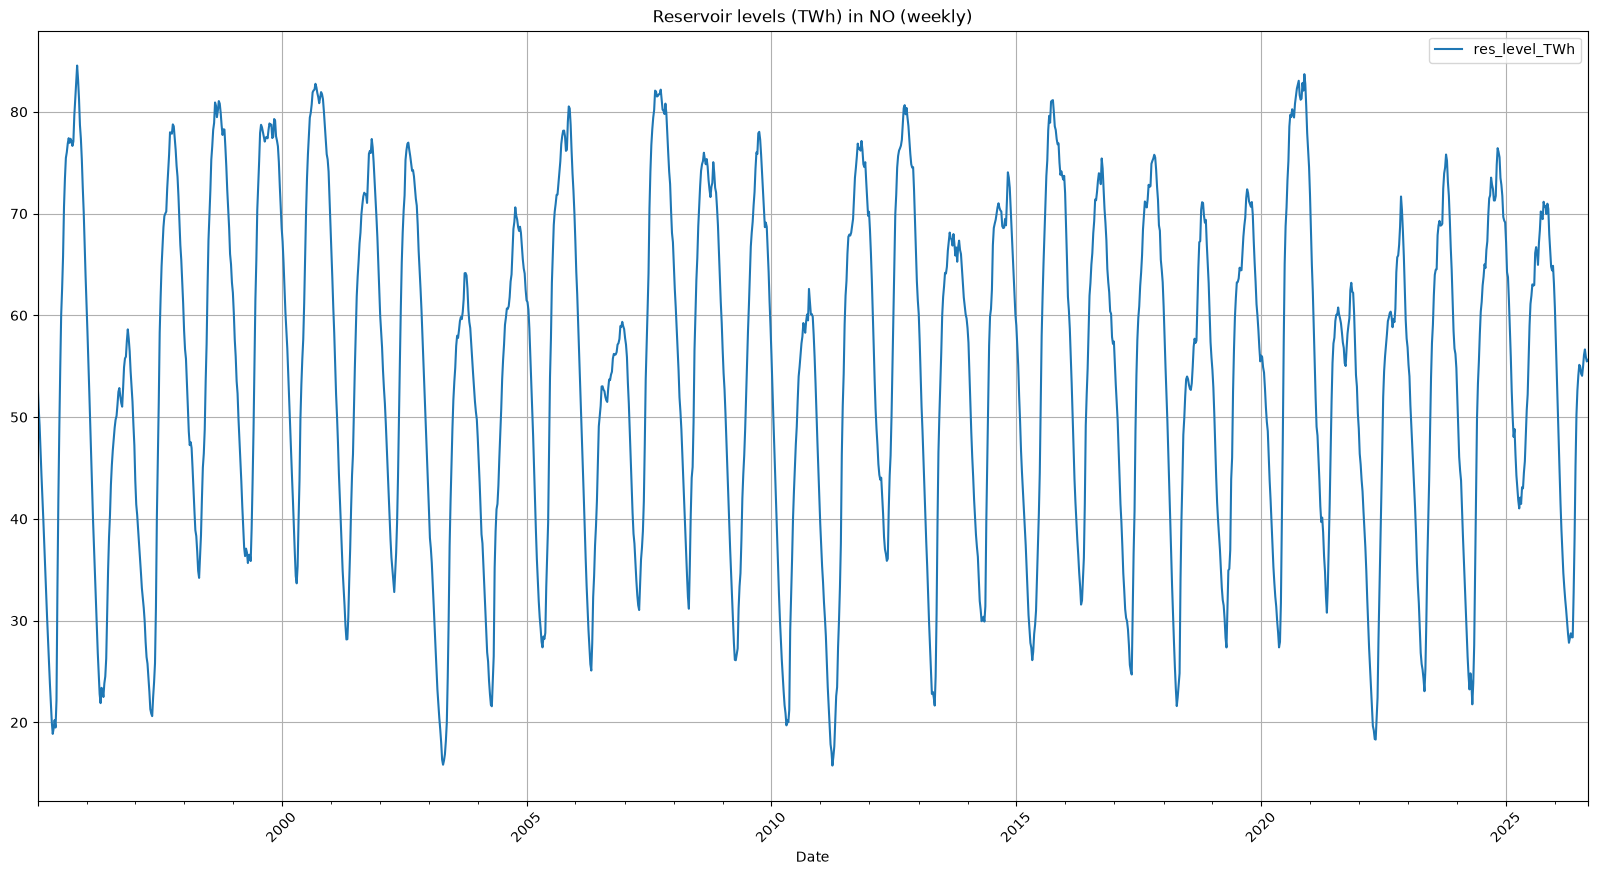

In [ ]:
# Creating a subset of the dataframe for area_type NO
subset_2 = df[df['area_type'] == 'NO'] 

# Plotting the reservoirs levels in TWh in area_type NO over time with instructions for figure size, title, x- and y-labels, and legend
ax2 = subset_2.plot(x='Date', 
              y='res_level_TWh',
              kind='line', 
              title='Reservoir levels (TWh) in NO (weekly)', 
              figsize=(20,10),
              rot=45, 
              grid=True)

ax2.legend(["Reservoir Level (TWh)"])
# Making sure the plot is displayed
plt.show()

### Reservoir levels in area type EL (Area nr. 1-5)

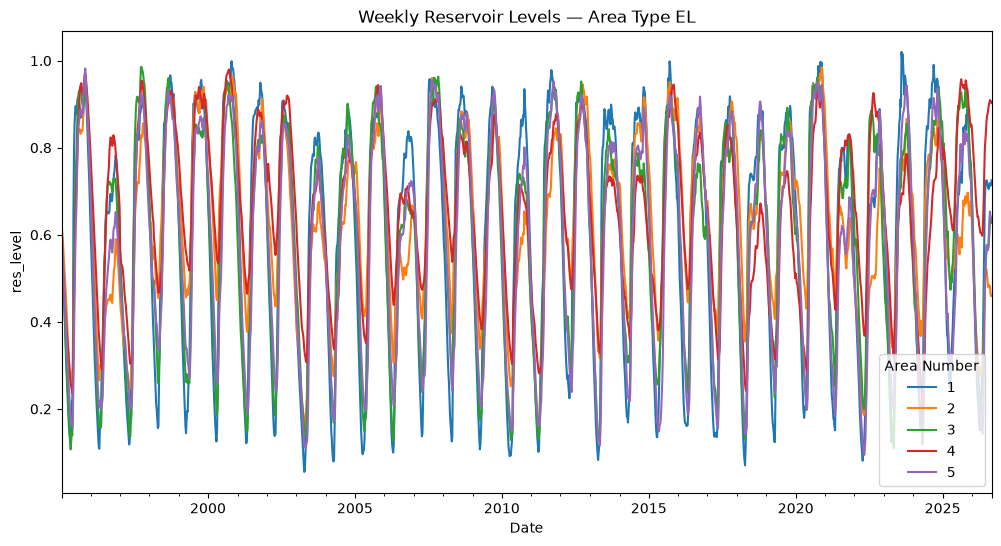

In [37]:
# Plotting the reservoir levels in area_type EL area_nr 1-5 over time

# Creating a subset of the dataframe for area_type EL
el = df[df['area_type'] == 'EL'] 

# Creating a pivot table with Date as index, area_nr as columns, and res_level as values
pivoted = el.pivot_table(index='Date', columns='area_nr', values='res_level') 

# Plotting the pivoted dataframe with instructions for figure size, title, x- and y-labels, and legend
pivoted.plot(figsize=(12, 6))
plt.title('Weekly Reservoir Levels — Area Type EL')
plt.xlabel('Date')
plt.ylabel('res_level')
plt.legend(title='Area Number',loc='lower right')

# Making sure the plot is displayed
plt.show()

### Change in reservoir levels in area type NO

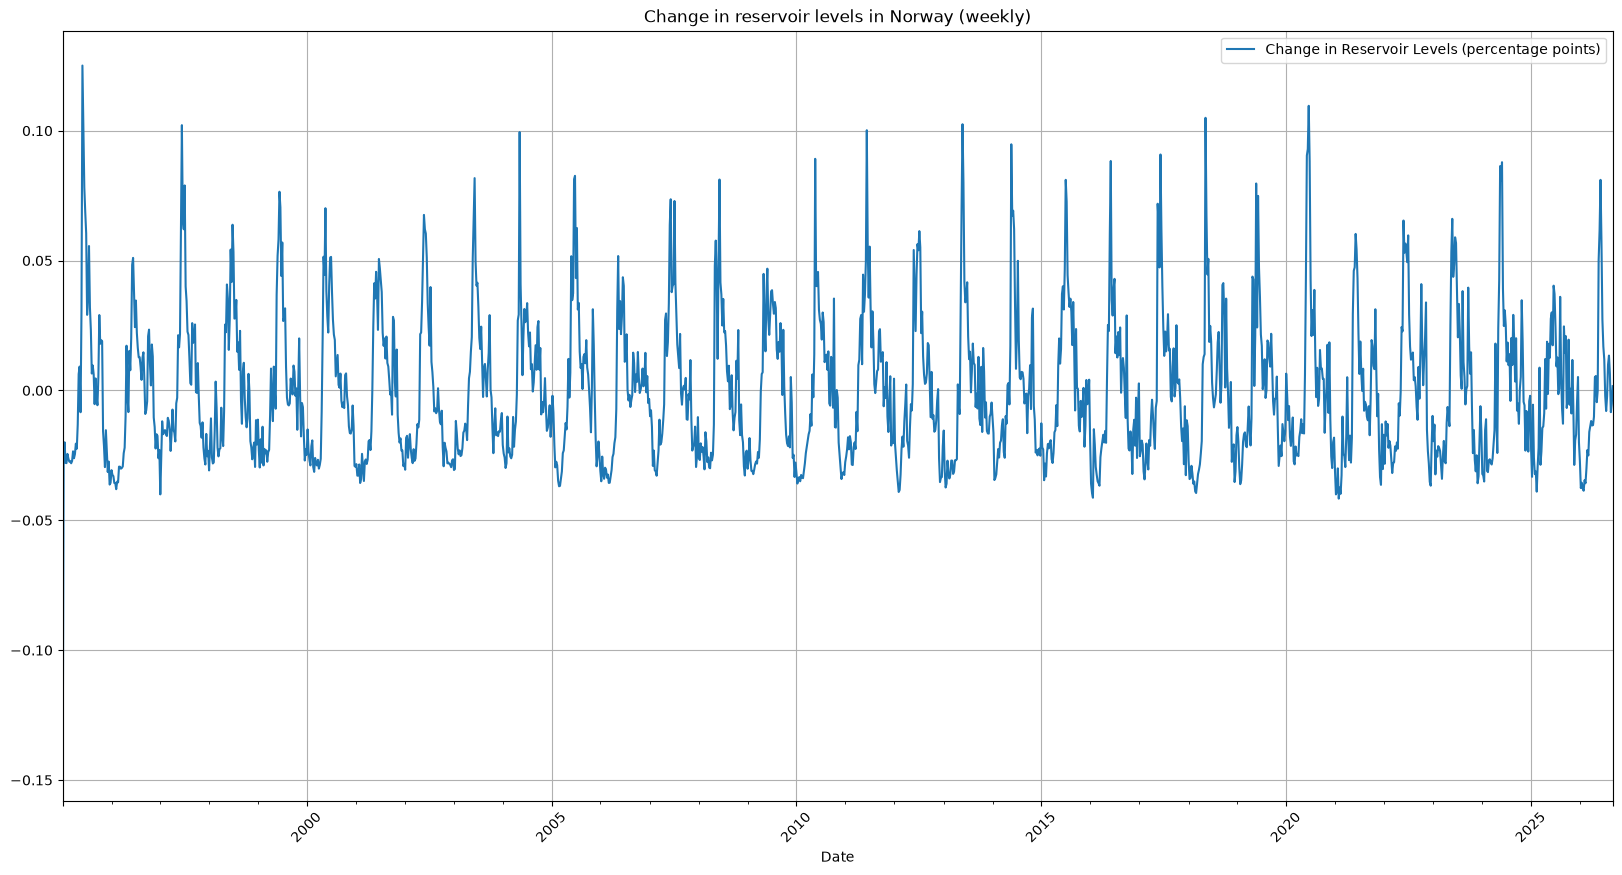

In [ ]:
# Plotting the change in reservoir levels in area_type NO over time
subset_3 = df[df['area_type'] == 'NO'] # Creating a subset of the dataframe for area_type NO

# Plotting the change in reservoir levels in area_type NO over time with instructions for figure size, title, x- and y-labels, and legend
ax3 = subset_3.plot(x='Date', 
              y='change_res_level',
              kind='line', 
              title='Change in reservoir levels in Norway (weekly)', 
              figsize=(20,10),
              rot=45, 
              grid=True)

# Renaming the legend to be easier to understand
ax3.legend(['Change in Reservoir Levels (percentage points)'])
# Making sure the plot is displayed
plt.show()

### Previous Reservoir Levels for area type NO

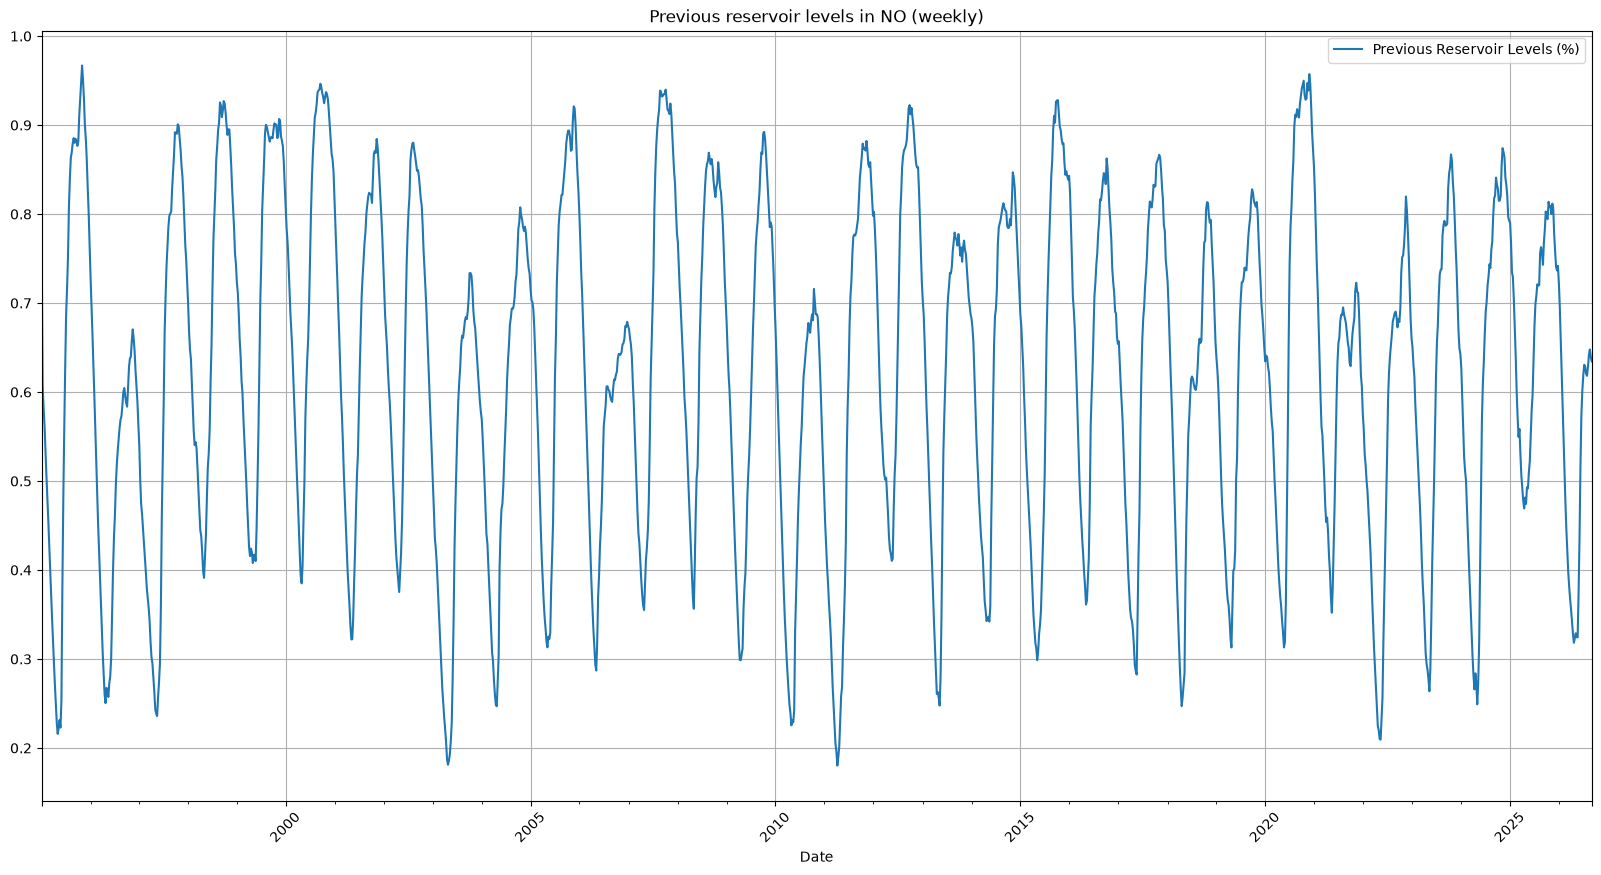

In [39]:
# Plotting the reservoir levels in NO over time

# Creating a subset of the dataframe for previous reservoir levels in area_type NO over time
subset_4 = df[df['area_type'] == 'NO'] 

# Creating an Axes object plotting the previous reservoir levels in area_type NO over time 
# with instructions for figure size, title, grid, x- and y-labels (rotation for x-labels), and legend
ax4 = subset_4.plot(x = 'Date', 
              y = 'prev_res_level', 
              kind = 'line', 
              title = 'Previous reservoir levels in NO (weekly)', 
              figsize = (20,10),
              rot = 45, 
              grid = True,
              legend=True)

# Renaming the legend
ax4.legend(['Previous Reservoir Levels (%)'])

# Making sure the plot is displayed
plt.show()

### Plotting all columns together (NO)

Plotting the reservoir data for 'NO' over time.

The CSV columns [iso_year, iso_week, next_publish_date] are excluded from
plotting because they are either redundant with the date (iso_aar/iso_uke)
or not a numeric series (next_publish_date is itself a date/metadata
field, not a value to plot).

Because the remaining numeric columns have very different scales
(e.g. fill ratio is a fraction (0-1), while capacity_TWh and res_level_TWh
are in TWh), plotting them together only makes visual sense if
they are normalized to a common scale. Capacity is excluded for plotting as it is constant over time, 
meaning that plotting it would just be straight line. 
There is used a min-max normalization (0-1 range) for each column independently, with clearly labeled plot to show that the y-axis is a normalized/relative scale, not the original units.

Note: Fill volume and fill ratio overlap perfectly once normalized as Fill volume = Capacity * Fill Ratio. 
This means that in the plot below, they will be directly on top of each other and hard to distinguish visually. 
The previous fill ratio can be seen if looking very carefully at the plot, but when plotting the whole period 
it will be hard to distinguish one week from another.

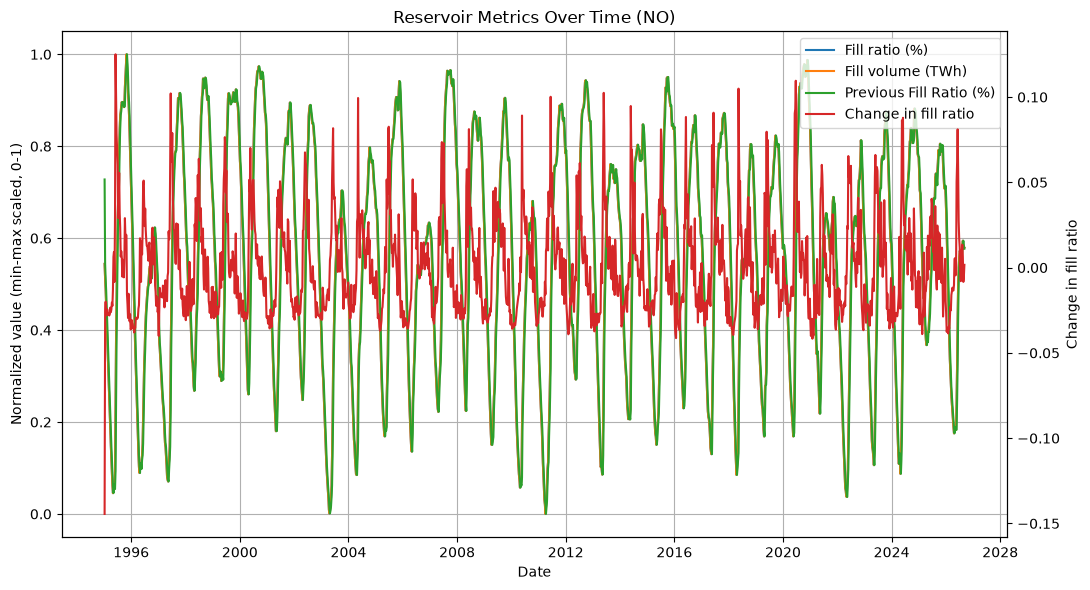

In [ ]:
# The code for filtering and then plotting

# Redefining the dataframe to be a subset for only area type 'NO'
df = df[df["area_type"] == 'NO']

# Raises an error if no rows are left after the filter (should work if everything earlier in the notebook works)
if df.empty:
    raise ValueError(f"No rows found for area_type == {'NO'}")

# Selecting columns to plot
plot_cols = ['res_level', 'res_level_TWh', 'prev_res_level', 'change_res_level']

# Adding a dictionary to change the labels for the legends in the plots
legend_labels = {
    "res_level": "Fill ratio (%)",
    "res_level_TWh": "Fill volume (TWh)",
    "prev_res_level": "Previous Fill Ratio (%)",
    "change_res_level": "Change in fill ratio",
}

# Split into "left axis" columns (everything except the change column)
# and the change column going on the right axis
left_cols = [c for c in plot_cols if c != "change_res_level"]
right_col = "change_res_level"

# Normalizing each column going in the "left side" of the plot independently
df_norm = df.copy()
for col in left_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    span = col_max - col_min
    df_norm[col] = 0.0 if span == 0 else (df[col] - col_min) / span

# Creating the figure and subplot ax1 for left_cols
fig, ax1 = plt.subplots(figsize=(11, 6))

# Left axis: everything except change in reservoir levels
for col in left_cols:
    label = legend_labels.get(col, col)
    ax1.plot(df["Date"], 
             df_norm[col], 
             label=label)

# Setting the labels for subplot 1 and adding a grid
ax1.set_xlabel("Date")
ax1.set_ylabel("Normalized value (min-max scaled, 0-1)")
ax1.grid(True)

# Right axis: Change in Fill Ratio
ax2 = ax1.twinx()
ax2.plot(df["Date"], 
         df[right_col],
          color="tab:red", 
          label=legend_labels.get(right_col, right_col))

# Setting the label for the y-axis for the subplot with axis on the right side (change in fill ratio)
ax2.set_ylabel("Change in fill ratio")

# Combining legend from both axes and setting the locating to the upper right of the plot
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# Setting the title of the plot
ax1.set_title("Reservoir Metrics Over Time (NO)")

# Makes sure labels don't overlap
fig.tight_layout()

# Making sure the plots are shown
plt.show()